# Ejercicio Módulo 6 - Detector de SPAM
**Inteligencia Artificial - CEIA - FIUBA**

**Daniel Alejandro Acero Varela**

Uno de los problemas más comunes en clasificación es la detección de correos electrónicos no deseados (SPAM). Uno de los primeros modelos utilizados para abordar este problema fue el clasificador de Bayes ingenuo (Naive Bayes). La detección de SPAM sigue siendo un desafío en el mundo digital, ya que los emisores de este tipo de mensajes continúan adaptando sus estrategias para evadir los filtros.

Además del clasificador de Bayes ingenuo, se han desarrollado y aplicado técnicas más avanzadas, como algoritmos de aprendizaje automático, redes neuronales y métodos basados en reglas.

En este ejercicio utilizaremos un conjunto de datos que contiene 4601 observaciones de correos electrónicos, de los cuales 2788 son legítimos y 1813 son SPAM. Dado que el contenido de los correos es un tipo de dato no estructurado, es necesario procesarlo. En este caso, el dataset ya ha sido preprocesado utilizando técnicas típicas de Procesamiento de Lenguaje Natural (NLP), como el conteo de la frecuencia de palabras observadas en los mensajes.

El procesamiento de lenguaje natural desempeña un rol fundamental en la detección de SPAM, ya que permite analizar el contenido textual y extraer características relevantes para la clasificación. Además del simple conteo de palabras, pueden aplicarse técnicas más sofisticadas, como la extracción de características semánticas o el análisis de sentimientos, para mejorar la precisión de los modelos.

En este dataset, se contabiliza la cantidad de ocurrencias de cada palabra en los distintos correos:

![spam counter](https://github.com/AlejoCNYT/intro_ia/blob/main/clase6/exercise/spam.png?raw=1)

Para preservar la privacidad de los mensajes, las frecuencias han sido normalizadas. El dataset está compuesto por 54 columnas de atributos denominadas:

- `word_freq_XXXX`: donde `XXXX` representa una palabra o símbolo. Los valores son enteros que van de 0 a 20.000.

Adicionalmente, incluye una columna llamada `spam`, que toma el valor 1 si el correo es SPAM, y 0 si es legítimo.

Los clasificadores de Bayes ingenuos fueron de los primeros filtros utilizados por las aplicaciones de correo electrónico. Se basan en el siguiente principio: partiendo de una probabilidad a priori de que un correo sea SPAM, la aparición de ciertas palabras puede modificar esa probabilidad a posteriori, indicando con mayor o menor certeza si un mensaje es o no SPAM.

### Carga del dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv("spambase.csv") # Cargamos los datos desde un archivo CSV
dataset.head(10)

X = dataset.iloc[:, :-1] # Seleccionamos todas las filas y todas las columnas menos la última como características
y = dataset.iloc[:, -1]  # Seleccionamos todas las filas y solo la última columna como etiquetas

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Dividimos los datos en conjuntos de entrenamiento y prueba

In [2]:
dataset.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
0,0,640,640,0,320,0,0,0,0,0,...,0,0,0,0,0,0,778,0,0,1
1,210,280,500,0,140,280,210,70,0,940,...,0,0,0,0,132,0,372,180,48,1
2,60,0,710,0,1230,190,190,120,640,250,...,60,0,0,10,143,0,276,184,10,1
3,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,137,0,137,0,0,1
4,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,135,0,135,0,0,1


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   word_freq_make        4601 non-null   int64
 1   word_freq_address     4601 non-null   int64
 2   word_freq_all         4601 non-null   int64
 3   word_freq_3d          4601 non-null   int64
 4   word_freq_our         4601 non-null   int64
 5   word_freq_over        4601 non-null   int64
 6   word_freq_remove      4601 non-null   int64
 7   word_freq_internet    4601 non-null   int64
 8   word_freq_order       4601 non-null   int64
 9   word_freq_mail        4601 non-null   int64
 10  word_freq_receive     4601 non-null   int64
 11  word_freq_will        4601 non-null   int64
 12  word_freq_people      4601 non-null   int64
 13  word_freq_report      4601 non-null   int64
 14  word_freq_addresses   4601 non-null   int64
 15  word_freq_free        4601 non-null   int64
 16  word_f

In [4]:
dataset.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,104.553358,213.014345,280.656379,65.424908,312.222995,95.900891,114.207564,105.294501,90.067377,239.413171,...,179.823734,5.444469,31.869159,38.574440,139.030428,16.975875,269.068898,75.810259,44.237992,0.394045
std,305.357562,1290.574888,504.142884,1395.151370,672.511666,273.824083,391.440302,401.071452,278.615864,644.755399,...,911.118627,76.274271,285.734646,243.470469,270.355374,109.394164,815.669848,245.879440,429.341596,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,420.000000,0.000000,380.000000,0.000000,0.000000,0.000000,0.000000,160.000000,...,0.000000,0.000000,0.000000,0.000000,188.000000,0.000000,315.000000,52.000000,0.000000,1.000000
max,4540.000000,14280.000000,5100.000000,42810.000000,10000.000000,5880.000000,7270.000000,11110.000000,5260.000000,18180.000000,...,22050.000000,2170.000000,10000.000000,4385.000000,9752.000000,4081.000000,32478.000000,6003.000000,19829.000000,1.000000


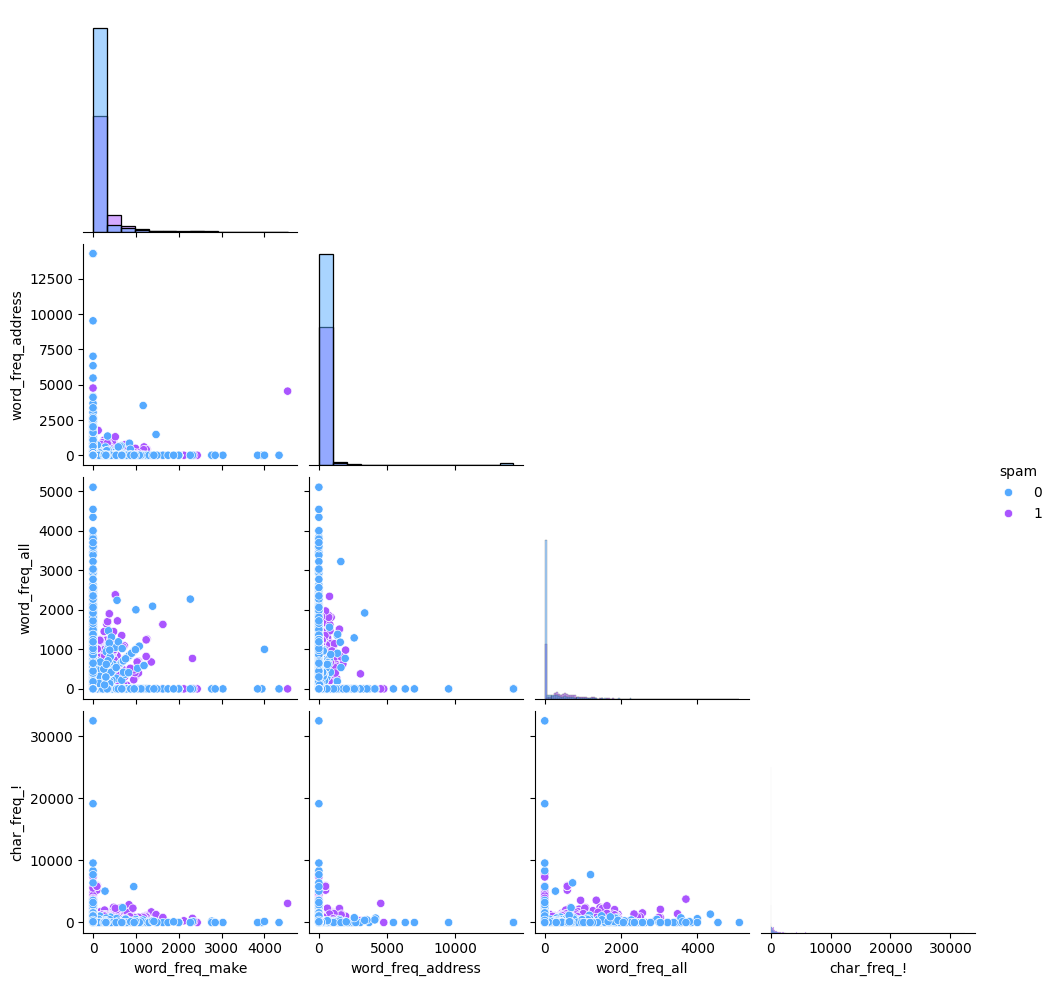

In [5]:
# Sélectionner quelques colonnes pour éviter de saturer la mémoire et le temps d'affichage
colonnes_interet = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'char_freq_!', 'spam']
sns.pairplot(data=dataset[colonnes_interet], diag_kind="hist", hue="spam", palette="cool", corner=True);

### Armado de modelos

En esta sección completaremos las partes que faltan:

- Cree una regresión logística utilizando un **Pipeline** de scikit-learn que incluya una etapa de estandarización de los atributos.
- Cree un modelo de **Bayes ingenuo** (sin aplicar normalización). Seleccione la implementación que considere más apropiada para este problema de entre las que ofrece scikit-learn.

In [7]:
from sklearn.pipeline import Pipeline
# COMPLETAR: Importar las librerías necesarias

# Creamos el pipeline de regresion logistica
log_reg = Pipeline([
   # COMPLETAR: Agregar una etapa de estandarización
   # COMPLETAR: Agregar la regresión logística
])

# Creamos el modelo Bayesiano Ingenuo
naive_bayes = # COMPLETAR: Crear el modelo de Bayes Ingenuo

# Entrenamos los modelos
log_reg.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

SyntaxError: invalid syntax (2335058113.py, line 11)

In [ ]:
from sklearn.model_selection import train_test_split

# Armamos un DataFrame con los features
X = dataset.drop(columns=["spam", "label_binary"])
# Y con la variable dependiente (target)
y = dataset["label_binary"]

In [ ]:
print(f"X es de tipo: {type(X)}")
print(f"El shape es de 2D: {X.shape}")

In [ ]:
print(f"El label es de tipo: {type(y)}")
print(f"El shape es de 1D: {y.shape}")

In [ ]:
# Proporción de clases
y.value_counts()

In [ ]:
# Separando nuestro dataset en entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

print("Observaciones de X_train:",X_train.shape[0])
print("Observaciones de y_train:",y_train.size)
print("Observaciones de X_test:",len(X_test))
print("Observaciones de y_test:",len(y_test))

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Entrenamos el escalador solo con el set de entrenamiento
X_train_scaled = sc.fit_transform(X_train)
# Y transformamos el set de testeo
X_test_scaled = sc.transform(X_test)

### Primer modelo de regresión logística

Podemos construir un primer modelo utilizando un solo atributo para observar cómo se comporta la probabilidad de clasificación. De los gráficos de distribución vimos que el **ancho del pétalo** es una variable que parece separar bastante bien a la clase `virginica` del resto.

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Entrenamos el escalador solo con el set de entrenamiento
X_train_scaled = sc.fit_transform(X_train)
# Y transformamos el set de testeo
X_test_scaled = sc.transform(X_test)

In [ ]:
X_train_one = X_train[["word_freq_all"]]
X_test_one = X_test[["word_freq_all"]]

In [ ]:
plt.figure(figsize=(5, 3))
plt.scatter(X_train_one, y_train, marker="x", color="#ff48fd")
plt.xlabel("word_freq_all")
plt.ylabel("p(x)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ["word_freq_all"]) # Escalamos la variable numérica
    ]
)

# Pipeline: preprocesamiento + modelo
log_1_attr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(random_state=0))
])

log_1_attr

In [ ]:
log_1_attr.fit(X_train_one, y_train)

In [ ]:
#Obtengamos la función logistica
xx = np.linspace(np.min(X_train_one), np.max(X_train_one), 1000)
xx = pd.DataFrame({"word_freq_all": xx})
# Usando el método que nos da las probabilidades
yy = log_1_attr.predict_proba(xx)

plt.figure(figsize=(5, 3))
plt.plot([-1000, 100000], [0.5, 0.5], linestyle="--", color="gray")
plt.scatter(X_train_one, y_train, marker="x", color="#ff48fd")
plt.plot(xx, yy[:, 1], color="#007aff")
plt.xlabel("word_freq_all")
plt.ylabel("p(x)")
plt.xlim([np.min(X_train_one) - 0.1, np.max(X_train_one) + 0.1])
plt.tight_layout()
plt.show()

In [ ]:
two_col = ["word_freq_our", "word_freq_table"]
X_train_two = X_train[two_col]
X_test_two = X_test[two_col]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), two_col)
    ]
)

log_2_attr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(random_state=0))
])

# Entrenamos
log_2_attr.fit(X_train_two, y_train)

In [ ]:
# Creamos la malla de puntos para graficar la frontera de decisión:
X_set, y_set = X_train_two.to_numpy(), y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 0.2, stop=X_set[:, 0].max() + 0.2, step=0.005),
    np.arange(start=X_set[:, 1].min() - 0.2, stop=X_set[:, 1].max() + 0.2, step=0.005)
)
X_cont = pd.DataFrame(np.array([X1.ravel(), X2.ravel()]).T, columns=pd.Index(two_col))

In [ ]:
from matplotlib.colors import ListedColormap

colormap_frontier=('#ffb7fe', '#93c7ff')
colormap_points=('#ff48fd', '#007aff')

plt.figure(figsize=(5, 3))
plt.contourf(
    X1, X2, log_2_attr.predict(X_cont).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(colormap_frontier)
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Puntos de entrenamiento
lab = ["No Spam", "Spam"]
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=colormap_points[i], label=lab[i],
        s=15
    )

plt.xlabel(two_col[0])
plt.ylabel(two_col[1])
plt.legend(title="Planta")

plt.show()

In [ ]:
four_col = list(X_train.columns)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), four_col)
    ]
)

log_4_attr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(random_state=0))
])

# Entrenamos el modelo
log_4_attr.fit(X_train, y_train)

### Evaluación de modelos:

Para cada modelo, utilizando el dataset de evaluación, calcule:

- La **matriz de confusión**
- La **precisión (precision)** y la **recuperación (recall)**
- El **AUC (Área Bajo la Curva ROC)**

#### Regresión Logística

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluamos el modelo de regresion logistica
y_pred_logreg = log_reg.predict(X_test)
y_prob_logreg = log_reg.predict_proba(X_test)[:, 1]

# Calculamos las métricas
cm_logreg = # COMPLETAR: Calcular la matriz de confusión
precision_logreg = # COMPLETAR: Calcular la precisión
recall_logreg = # COMPLETAR: Calcular el recall
roc_auc_logreg = # COMPLETAR: Calculamos el AUC. OBS: Usamos las probabilidades para AUC

print('Regresión Logística:')
print(f'  Precisión: {precision_logreg}')
print(f'  Recall: {recall_logreg}')
print(f'  AUC: {roc_auc_logreg}')

In [ ]:
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg)
disp_logreg.plot()
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

In [ ]:
y_pred_1 = log_1_attr.predict(X_test_one)
y_pred_2 = log_2_attr.predict(X_test_two)
y_pred_4 = log_4_attr.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm_1_attr = confusion_matrix(y_test, y_pred_1)
cm_2_attr = confusion_matrix(y_test, y_pred_2)
cm_4_attr = confusion_matrix(y_test, y_pred_4)

cms = [cm_1_attr, cm_2_attr, cm_4_attr]
titles = ["Usando param 1", "Usando param 2",
    "Todos los param"]

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [ ]:
def sens_spec(cm):
    sensitivity = cm[1, 1] / np.sum(cm[1, :])
    specifity = cm[0, 0] / np.sum(cm[0, :])
    balanced_accuracy = (sensitivity + specifity) / 2

    return sensitivity, specifity, balanced_accuracy

In [ ]:
sensitivity_1_attr, specifity_1_attr, balanced_accuracy_1_attr = sens_spec(cm_1_attr)
sensitivity_2_attr, specifity_2_attr, balanced_accuracy_2_attr = sens_spec(cm_2_attr)
sensitivity_4_attr, specifity_4_attr, balanced_accuracy_4_attr = sens_spec(cm_4_attr)

print(titles[0])
print(f"Sensibilidad: {sensitivity_1_attr}")
print(f"Especificidad: {specifity_1_attr}")
print(f"Exactitud balanceada: {balanced_accuracy_1_attr}\n")

print(titles[1])
print(f"Sensibilidad: {sensitivity_2_attr}")
print(f"Especificidad: {specifity_2_attr}")
print(f"Exactitud balanceada: {balanced_accuracy_2_attr}\n")

print(titles[2])
print(f"Sensibilidad: {sensitivity_4_attr}")
print(f"Especificidad: {specifity_4_attr}")
print(f"Exactitud balanceada: {balanced_accuracy_4_attr}")

In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
print(titles[0])
print(f"Precision: {precision_score(y_test, y_pred_1)}")
print(f"Recuperación: {recall_score(y_test, y_pred_1)}\n")

print(titles[1])
print(f"Precision: {precision_score(y_test, y_pred_2)}")
print(f"Recuperación: {recall_score(y_test, y_pred_2)}\n")

print(titles[2])
print(f"Precision: {precision_score(y_test, y_pred_4)}")
print(f"Recuperación: {recall_score(y_test, y_pred_4)}")

In [ ]:
from sklearn.metrics import f1_score, fbeta_score

print(titles[0])
print(f"F1-score: {f1_score(y_test, y_pred_1)}")
print(f"F2-score: {fbeta_score(y_test, y_pred_1, beta=2)}")
print(f"F0.5-score: {fbeta_score(y_test, y_pred_1, beta=0.5)}\n")

print(titles[1])
print(f"F1-score: {f1_score(y_test, y_pred_2)}")
print(f"F2-score: {fbeta_score(y_test, y_pred_2, beta=2)}")
print(f"F0.5-score: {fbeta_score(y_test, y_pred_2, beta=0.5)}\n")

print(titles[2])
print(f"F1-score: {f1_score(y_test, y_pred_4)}")
print(f"F2-score: {fbeta_score(y_test, y_pred_4, beta=2)}")
print(f"F0.5-score: {fbeta_score(y_test, y_pred_4, beta=0.5)}\n")

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
target_names = ["No Spam", "Spam"]

print(titles[0])
print(classification_report(y_test, y_pred_1, target_names=target_names))

In [ ]:
print(titles[1])
print(classification_report(y_test, y_pred_2, target_names=target_names))

In [ ]:
print(titles[2])
print(classification_report(y_test, y_pred_4, target_names=target_names))

In [ ]:
p_pred_1 = log_1_attr.predict_proba(X_test_one)
p_pred_2 = log_2_attr.predict_proba(X_test_two)
p_pred_4 = log_4_attr.predict_proba(X_test)

In [ ]:
p_pred_1[:5, :]

In [ ]:
from sklearn.metrics import roc_curve

fpr_1_attr, tpr_1_attr, thr_1_attr = roc_curve(y_test, p_pred_1[:, 1])
fpr_2_attr, tpr_2_attr, thr_2_attr = roc_curve(y_test, p_pred_2[:, 1])
fpr_4_attr, tpr_4_attr, thr_4_attr = roc_curve(y_test, p_pred_4[:, 1])

In [ ]:
colors = ["#00FFFF", "#FF00FF", "#FF1493", "#00BFFF", "#FF6347"]

plt.figure(figsize=(5, 3))
plt.plot(fpr_1_attr, tpr_1_attr, label=titles[0], color=colors[1])
plt.plot(fpr_2_attr, tpr_2_attr, label=titles[1], color=colors[2])
plt.plot(fpr_4_attr, tpr_4_attr, label=titles[2], color=colors[3])
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout();

In [ ]:
from sklearn.metrics import roc_auc_score

print(titles[0])
print(f"AUC: {roc_auc_score(y_test, p_pred_1[:, 1])}\n")

print(titles[1])
print(f"AUC: {roc_auc_score(y_test, p_pred_2[:, 1])}\n")

print(titles[2])
print(f"AUC: {roc_auc_score(y_test, p_pred_4[:, 1])}")

In [ ]:
X = df_iris.drop(columns=["label", "label_binary"])
y = df_iris["label"]

y.value_counts()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), four_col)
    ]
)

multi_class_log_4_attr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(random_state=0))
])

multi_class_log_4_attr.fit(X_train, y_train)

In [ ]:
multi_class_log_4_attr.predict(X_train.iloc[0:1, :])

In [ ]:
multi_class_log_4_attr.predict_proba(X_train.iloc[0:1, :])

In [ ]:
multi_class_log_4_attr['regressor'].classes_

In [ ]:
# Obtenemos la salida probabilística
p_obs = multi_class_log_4_attr.predict_proba(X_train.iloc[0:1, :])

# Obtenemos la posición del valor máximo
pos_max = np.argmax(p_obs)

# Y obtenemos la clase correspondiente
print(multi_class_log_4_attr['regressor'].classes_[pos_max])

In [ ]:
y_pred = multi_class_log_4_attr.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), two_col)
    ]
)

multi_class_log_2_attr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression(random_state=0))
])

multi_class_log_2_attr.fit(X_train[two_col], y_train)

In [ ]:
# Creamos la malla de puntos para el gráfico
X_set, y_set = X_train_two.to_numpy(), y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 0.2, stop=X_set[:, 0].max() + 0.2, step=0.005),
    np.arange(start=X_set[:, 1].min() - 0.2, stop=X_set[:, 1].max() + 0.2, step=0.005)
)
X_cont = pd.DataFrame(np.array([X1.ravel(), X2.ravel()]).T, columns=pd.Index(two_col))

In [ ]:
from matplotlib.colors import ListedColormap

colormap_frontier=('#ffb7fe', '#93c7ff', "#a9e5c5")
colormap_points=('#ff48fd', '#007aff', "#44c57f")

# Crear el gráfico de contorno
plt.figure(figsize=(5, 3))
plt.contourf(
    X1, X2,
    np.argmax(multi_class_log_2_attr.predict_proba(X_cont), axis=1).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(colormap_frontier)
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Graficar los puntos de entrenamiento
lab = ['setosa', 'versicolor', 'virginica']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=colormap_points[i], label=lab[i],
        s=15
    )

plt.xlabel(two_col[0])
plt.ylabel(two_col[1])
plt.legend(title="Planta")

plt.show()

#### Modelo Bayesiano Ingenuo

In [ ]:
# Evaluamos el modelo naive-bayes
y_pred_nb = naive_bayes.predict(X_test)
y_prob_nb = naive_bayes.predict_proba(X_test)[:, 1]

cm_nb = # ...
precision_nb = # ...
recall_nb = # ...
roc_auc_nb = # ...

print('Naive Bayes:')
print(f'  Precisión: {precision_nb}')
print(f'  Recall: {recall_nb}')
print(f'  AUC: {roc_auc_nb}')

In [8]:
dataset["spam"].value_counts()

,count
spam,
0,2788
1,1813


In [10]:
dataset_neg = dataset[dataset["spam"] == 0].drop(columns="spam")
dataset_pos = dataset[dataset["spam"] == 1].drop(columns="spam")

mean_tfidf_neg = dataset_neg.mean().sort_values(ascending=False) # Ordena > medias
mean_tfidf_pos = dataset_pos.mean().sort_values(ascending=False)

# Top 5 palabras con mayor TF-IDF promedio en cada clase
print("🔴 Palabras más representativas de la clase NEGATIVA:")
print(mean_tfidf_neg.head(5))

print("\n🟢 Palabras más representativas de la clase POSITIVA:")
print(mean_tfidf_pos.head(5))

del mean_tfidf_neg, mean_tfidf_pos

🔴 Palabras más representativas de la clase NEGATIVA:
word_freq_you       1270.337877
word_freq_george    1265.265065
word_freq_hp         895.472023
word_freq_will       536.322812
word_freq_your       438.700861
dtype: float64

🟢 Palabras más representativas de la clase POSITIVA:
word_freq_you     2264.533370
word_freq_your    1380.362383
word_freq_will     549.972421
word_freq_free     518.361831
word_freq_our      513.954220
dtype: float64


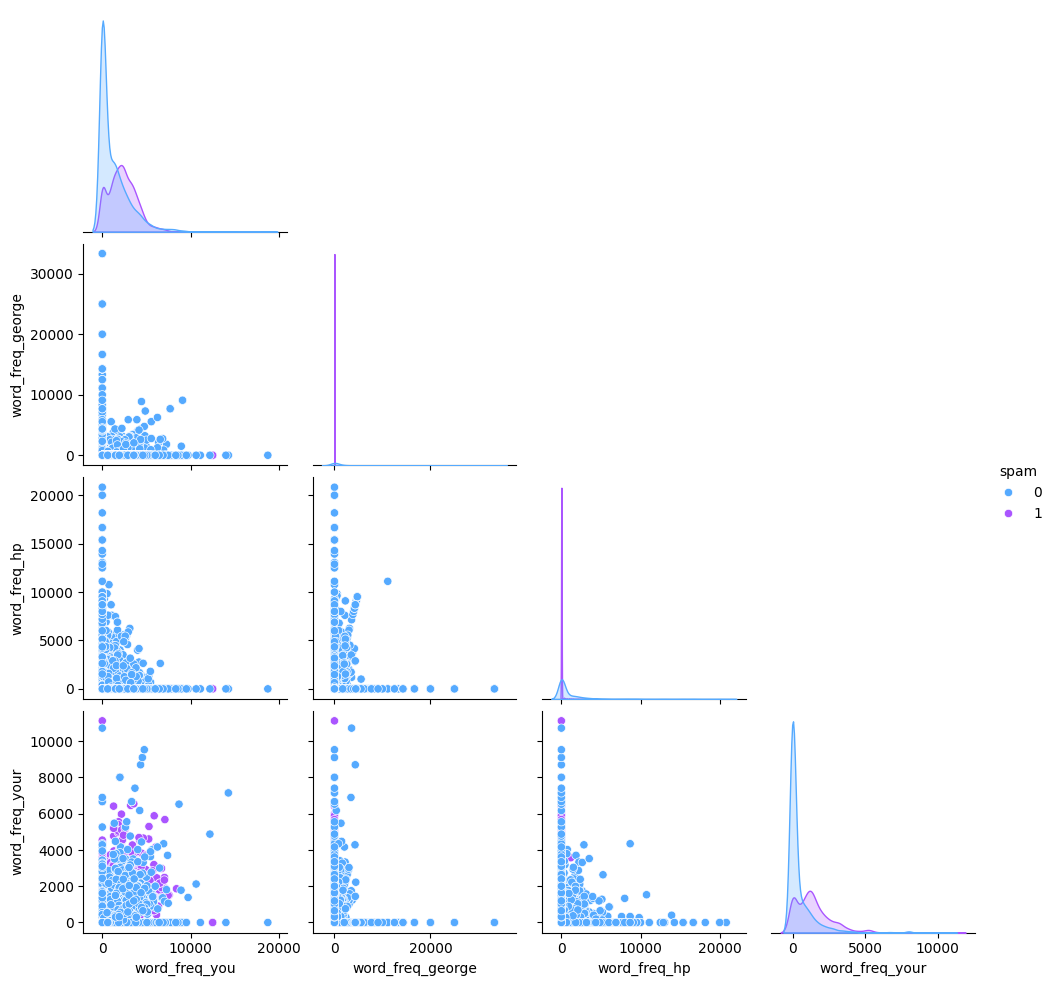

In [12]:
col_sel = ["word_freq_you", "word_freq_george", "word_freq_hp", "word_freq_your", "spam"]
dataset_visualization = dataset[col_sel]

sns.pairplot(data=dataset_visualization, diag_kind="kde", hue="spam",
    palette="cool", corner=True);

In [15]:
from sklearn.naive_bayes import MultinomialNB

In [16]:
from sklearn.model_selection import train_test_split

# División en variables independientes y target
X = dataset.drop(columns=["spam"])
y = dataset["spam"]

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

# Separar un set de validación dentro del entrenamiento
X_train_temp, X_val, y_train_temp, y_val = train_test_split(X_train, y_train,
    test_size=0.1, random_state=42)

In [17]:
model = MultinomialNB()

model.fit(X_train_temp, y_train_temp)
accuracy_train = model.score(X_train_temp, y_train_temp)
accuracy_validation = model.score(X_val, y_val)

print(f"La exactitud de entrenamiento es {accuracy_train}")
print(f"La exactitud de validación es {accuracy_validation}")

del X_train_temp, y_train_temp, X_val, y_val

La exactitud de entrenamiento es 0.8657694962042788
La exactitud de validación es 0.8540372670807453


In [18]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix


def sens_spec(cm):
    sensitivity = cm[1, 1] / np.sum(cm[1, :])
    specifity = cm[0, 0] / np.sum(cm[0, :])
    balanced_accuracy = (sensitivity + specifity) / 2

    return sensitivity, specifity, balanced_accuracy

cm = confusion_matrix(y_test, y_pred)
sensitivity, specifity, balanced_accuracy = sens_spec(cm)

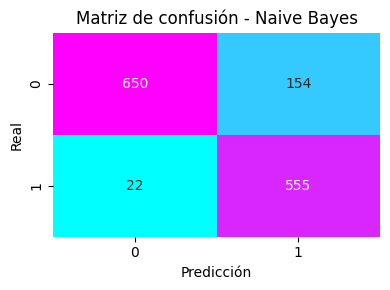

In [21]:
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Naive Bayes")

plt.tight_layout()
plt.show()

In [22]:
print(f"Sensibilidad: {sensitivity}")
print(f"Especificidad: {specifity}")
print(f"Exactitud balanceada: {balanced_accuracy}")

Sensibilidad: 0.9618717504332756
Especificidad: 0.8084577114427861
Exactitud balanceada: 0.8851647309380308


In [23]:
from sklearn.metrics import classification_report

target_names = ["Negativo", "Positivo"]
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    Negativo       0.97      0.81      0.88       804
    Positivo       0.78      0.96      0.86       577

    accuracy                           0.87      1381
   macro avg       0.88      0.89      0.87      1381
weighted avg       0.89      0.87      0.87      1381



In [ ]:
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_logreg.plot()
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

In [24]:
p_pred = model.predict_proba(X_test)

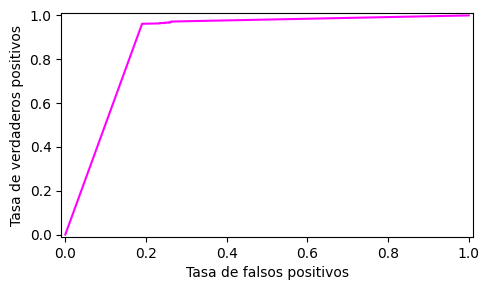

In [25]:
from sklearn.metrics import roc_curve

colors = ["#00FFFF", "#FF00FF", "#FF1493", "#00BFFF", "#FF6347"]

fpr, tpr, thr = roc_curve(y_test, p_pred[:, 1])

plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color=colors[1])
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.tight_layout();

In [26]:
from sklearn.metrics import roc_auc_score

print(f"AUC: {roc_auc_score(y_test, p_pred[:, 1])}\n")

AUC: 0.8883463962682256



Completa la tabla de métricas:

| Modelo                        | Precision | Recall | AUC |
| ----------------------------- | --- | --- | ----- |
| Regresión Logistica              |     |     |       |
| Naive Bayes |     |     |       |


### Preguntas:

¿Cuál es el mejor modelo según cada métrica?

- Precision: ...
- Recall: ...
- AUC: ...

Viendo la matriz de confusión, ¿qué tipo de error comete más cada modelo?

- Regresión logística: ...
- Modelo Bayes ingenuo: ...

Según tu opinión, ¿cuál de los dos tipos de error considerás más importante en este problema?

...